# Titanic Survival Prediction using Logistic Regression

## Introduction

This project uses Logistic Regression to predict whether a passenger survived the Titanic disaster.

The project includes data loading, data exploration, preprocessing, feature selection, train-test splitting, model training, prediction, probability prediction, and model evaluation.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [5]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("Shape of dataset:", df.shape)

Shape of dataset: (891, 12)


In [7]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [9]:
df["Survived"].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [10]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features].copy()
y = df["Survived"]

In [11]:
X["Age"] = X["Age"].fillna(X["Age"].median())
X["Fare"] = X["Fare"].fillna(X["Fare"].median())
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])

In [12]:
X.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [13]:
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)

X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [14]:
X.dtypes


Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


In [17]:
model = LogisticRegression(max_iter=1000)

In [19]:
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [20]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]


In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.8100558659217877
Model Accuracy (%): 81.00558659217877


In [22]:
y_probability = model.predict_proba(X_test)

print("Probability Predictions:")
print(y_probability[:10])

Probability Predictions:
[[0.89000888 0.10999112]
 [0.77786006 0.22213994]
 [0.86543114 0.13456886]
 [0.11373855 0.88626145]
 [0.26359019 0.73640981]
 [0.06875179 0.93124821]
 [0.31600646 0.68399354]
 [0.90921227 0.09078773]
 [0.24249543 0.75750457]
 [0.07816499 0.92183501]]


In [23]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Survival Probability": y_probability[:, 1]
})

results.head(10)

,Actual,Predicted,Survival Probability
0,1,0,0.109991
1,0,0,0.222140
2,0,0,0.134569
3,1,1,0.886261
4,1,1,0.736410
5,1,1,0.931248
6,1,1,0.683994
7,0,0,0.090788
8,1,1,0.757505
9,1,1,0.921835


In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("========== MODEL EVALUATION ==========")
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

========== MODEL EVALUATION ==========
Accuracy: 0.8100558659217877
Accuracy Percentage: 81.00558659217877 %


In [25]:
print("========== ACTUAL VS PREDICTED ==========")

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results)

========== ACTUAL VS PREDICTED ==========
     Actual  Predicted
0         1          0
1         0          0
2         0          0
3         1          1
4         1          1
..      ...        ...
174       0          0
175       0          0
176       1          0
177       1          1
178       1          1

[179 rows x 2 columns]


In [26]:
y_probability = model.predict_proba(X_test)

print("========== PREDICTION PROBABILITIES ==========")
print(y_probability)

========== PREDICTION PROBABILITIES ==========
[[0.89000888 0.10999112]
 [0.77786006 0.22213994]
 [0.86543114 0.13456886]
 [0.11373855 0.88626145]
 [0.26359019 0.73640981]
 [0.06875179 0.93124821]
 [0.31600646 0.68399354]
 [0.90921227 0.09078773]
 [0.24249543 0.75750457]
 [0.07816499 0.92183501]
 [0.66477697 0.33522303]
 [0.93051004 0.06948996]
 [0.61380089 0.38619911]
 [0.85430395 0.14569605]
 [0.80212641 0.19787359]
 [0.06288622 0.93711378]
 [0.69823867 0.30176133]
 [0.31596223 0.68403777]
 [0.75482102 0.24517898]
 [0.66765626 0.33234374]
 [0.87905528 0.12094472]
 [0.59047597 0.40952403]
 [0.38559522 0.61440478]
 [0.86503945 0.13496055]
 [0.88980355 0.11019645]
 [0.93133016 0.06866984]
 [0.53654099 0.46345901]
 [0.77674182 0.22325818]
 [0.91862974 0.08137026]
 [0.40260646 0.59739354]
 [0.86183979 0.13816021]
 [0.33861039 0.66138961]
 [0.44321524 0.55678476]
 [0.38094345 0.61905655]
 [0.85811062 0.14188938]
 [0.87588006 0.12411994]
 [0.53975995 0.46024005]
 [0.31600646 0.68399354]
 [0

In [27]:
probability_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_Not_Survived": y_probability[:, 0],
    "Probability_Survived": y_probability[:, 1]
})

print("========== PREDICTION RESULTS ==========")
print(probability_results)

========== PREDICTION RESULTS ==========
     Actual  Predicted  Probability_Not_Survived  Probability_Survived
0         1          0                  0.890009              0.109991
1         0          0                  0.777860              0.222140
2         0          0                  0.865431              0.134569
3         1          1                  0.113739              0.886261
4         1          1                  0.263590              0.736410
..      ...        ...                       ...                   ...
174       0          0                  0.854645              0.145355
175       0          0                  0.846527              0.153473
176       1          0                  0.644697              0.355303
177       1          1                  0.145915              0.854085
178       1          1                  0.301751              0.698249

[179 rows x 4 columns]


In [28]:
print("Features used by the model:")
print(X.columns.tolist())

Features used by the model:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [29]:
# New passenger data

new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Age": [22],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [7.25],
    "Sex_male": [1],
    "Embarked_Q": [0],
    "Embarked_S": [1]
})

# Make prediction
new_prediction = model.predict(new_passenger)

# Get prediction probability
new_probability = model.predict_proba(new_passenger)

print("========== NEW PASSENGER PREDICTION ==========")

if new_prediction[0] == 1:
    print("Prediction: Passenger is likely to SURVIVE")
else:
    print("Prediction: Passenger is likely to NOT SURVIVE")

print("Probability of NOT SURVIVING:", new_probability[0][0])
print("Probability of SURVIVING:", new_probability[0][1])

========== NEW PASSENGER PREDICTION ==========
Prediction: Passenger is likely to NOT SURVIVE
Probability of NOT SURVIVING: 0.8725882052152418
Probability of SURVIVING: 0.12741179478475817


In [30]:
print("========== PASSENGER DETAILS ==========")
print("Passenger Class:", new_passenger["Pclass"].iloc[0])
print("Age:", new_passenger["Age"].iloc[0])
print("Sex:", "Male" if new_passenger["Sex_male"].iloc[0] == 1 else "Female")
print("Fare:", new_passenger["Fare"].iloc[0])

print("\n========== FINAL PREDICTION ==========")

if new_prediction[0] == 1:
    print("The model predicts that the passenger would SURVIVE.")
else:
    print("The model predicts that the passenger would NOT SURVIVE.")

========== PASSENGER DETAILS ==========
Passenger Class: 3
Age: 22
Sex: Male
Fare: 7.25

========== FINAL PREDICTION ==========
The model predicts that the passenger would NOT SURVIVE.


========== CONFUSION MATRIX ==========
[[90 15]
 [19 55]]


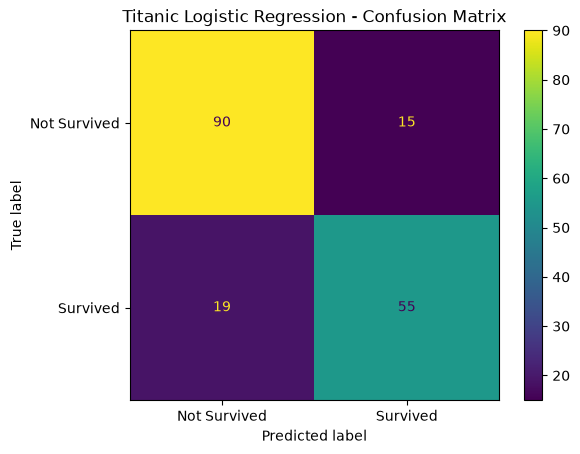

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("========== CONFUSION MATRIX ==========")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
)

disp.plot()
plt.title("Titanic Logistic Regression - Confusion Matrix")
plt.show()

In [32]:
from sklearn.metrics import classification_report

print("========== CLASSIFICATION REPORT ==========")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Survived", "Survived"]
))

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

Not Survived       0.83      0.86      0.84       105
    Survived       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [33]:
print("==========================================")
print("   TITANIC LOGISTIC REGRESSION MODEL")
print("==========================================")

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Accuracy:", round(accuracy * 100, 2), "%")

print("==========================================")

   TITANIC LOGISTIC REGRESSION MODEL
Training Samples: 712
Testing Samples: 179
Accuracy: 81.01 %
